In [1]:
from lib import epl 
from lib import OSN
from lib import readout
from lib import plots
import numpy as np
import pickle 
import random #remember to do this in class
from sklearn import datasets
import matplotlib.pyplot as plt
from preprocess import preprocessing as pre
import epl.src.computeResults as compResults
from numpy.matlib import repmat
#import epl.src.multi_pattern_learning.epl_multi_pattern_learning 
#from epl.src.multi_pattern_learning.epl_multi_pattern_learning import EPLMultiPatternLearning


LOAD AND GENERATE DATA


In [2]:
# load the digits dataset which consists of 8X8 images of digits
digits = datasets.load_digits()
images = digits.images
targets = digits.target
# create a map of {digt->list of images of the digits}
image_dict = {n : [] for n in range(10)}
for t, img in zip(targets, images):
    image_dict[t].append(img)

In [3]:

numPatterns = 6
#randomly choose 6 digits
digits = [0, 2, 4, 5, 7, 9]


In [4]:
#CAN STAY IN CODE

#define utility functions
#create the training dataset by choosing the appropriate images of the digts to be learned
def get_training_data(digits, fourX=True, idx=0):
    train_data = []
    for digit in digits:
        training_image = image_dict[digit][idx]
        print(training_image)
        training_image = np.ndarray.astype(training_image, int)
        if fourX: training_image = (training_image//4)*4
        training_image = np.ndarray.flatten(training_image).tolist()
        print(training_image)
        train_data.append(training_image)
    return train_data

In [5]:
# generate the training data
train_data = np.array(get_training_data(digits=digits))

[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]
[0, 0, 4, 12, 8, 0, 0, 0, 0, 0, 12, 12, 8, 12, 4, 0, 0, 0, 12, 0, 0, 8, 8, 0, 0, 4, 12, 0, 0, 8, 8, 0, 0, 4, 8, 0, 0, 8, 8, 0, 0, 4, 8, 0, 0, 12, 4, 0, 0, 0, 12, 4, 8, 12, 0, 0, 0, 0, 4, 12, 8, 0, 0, 0]
[[ 0.  0.  0.  4. 15. 12.  0.  0.]
 [ 0.  0.  3. 16. 15. 14.  0.  0.]
 [ 0.  0.  8. 13.  8. 16.  0.  0.]
 [ 0.  0.  1.  6. 15. 11.  0.  0.]
 [ 0.  1.  8. 13. 15.  1.  0.  0.]
 [ 0.  9. 16. 16.  5.  0.  0.  0.]
 [ 0.  3. 13. 16. 16. 11.  5.  0.]
 [ 0.  0.  0.  3. 11. 16.  9.  0.]]
[0, 0, 0, 4, 12, 12, 0, 0, 0, 0, 0, 16, 12, 12, 0, 0, 0, 0, 8, 12, 8, 16, 0, 0, 0, 0, 0, 4, 12, 8, 0, 0, 0, 0, 8, 12, 12, 0, 0, 0, 0, 8, 16, 16, 4, 0, 0, 0, 0, 0, 12, 16, 16, 8, 4, 0, 0, 0, 0, 0, 8, 16, 8, 0]
[[ 0.  0.  0.  1. 11.  0. 

In [6]:
def generateTestingData(trainingData, occlusionPercent, numTestSamples,
                        sensorDynamicRange=16):  #15 to 16
    """ generate synthetic testing data for EPL network"""
    data = trainingData
    p = occlusionPercent
    n = numTestSamples
    occludedData = []
    nsensors = len(data[0])

    for i in range(0, len(data)):
        ndim = len(data[i])  # dimension of data
        for j in range(0, n):
            occludedData.append([])
            affected_ids = random.sample(range(ndim), int(p * ndim))
            for k in range(0, ndim):
                if k in affected_ids:
                    occludedData[i * n + j].append(
                        random.randint(0, sensorDynamicRange))
                else:
                    occludedData[i * n + j].append(data[i][k])
    return occludedData
numTestSamples = 5
occlusionPercent = 0.2 # randomly perturb only 20% of the image pixels
test_data = np.array(generateTestingData(trainingData=train_data,
                                occlusionPercent=occlusionPercent,
                                numTestSamples=numTestSamples))

# plot train and test data

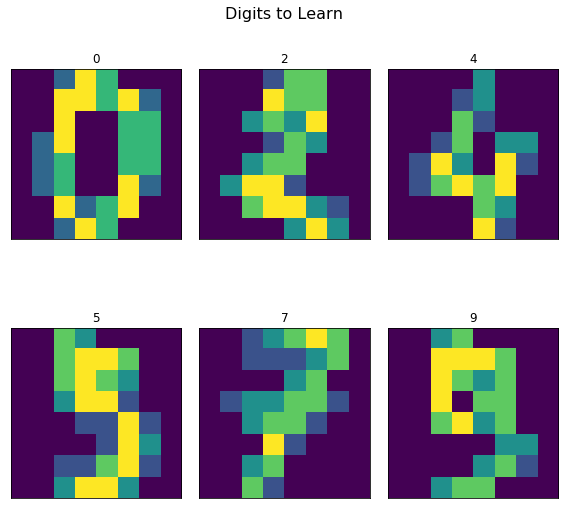

In [7]:
# Train Data
pre.plot_images(digits, train_data, title="Digits to Learn")

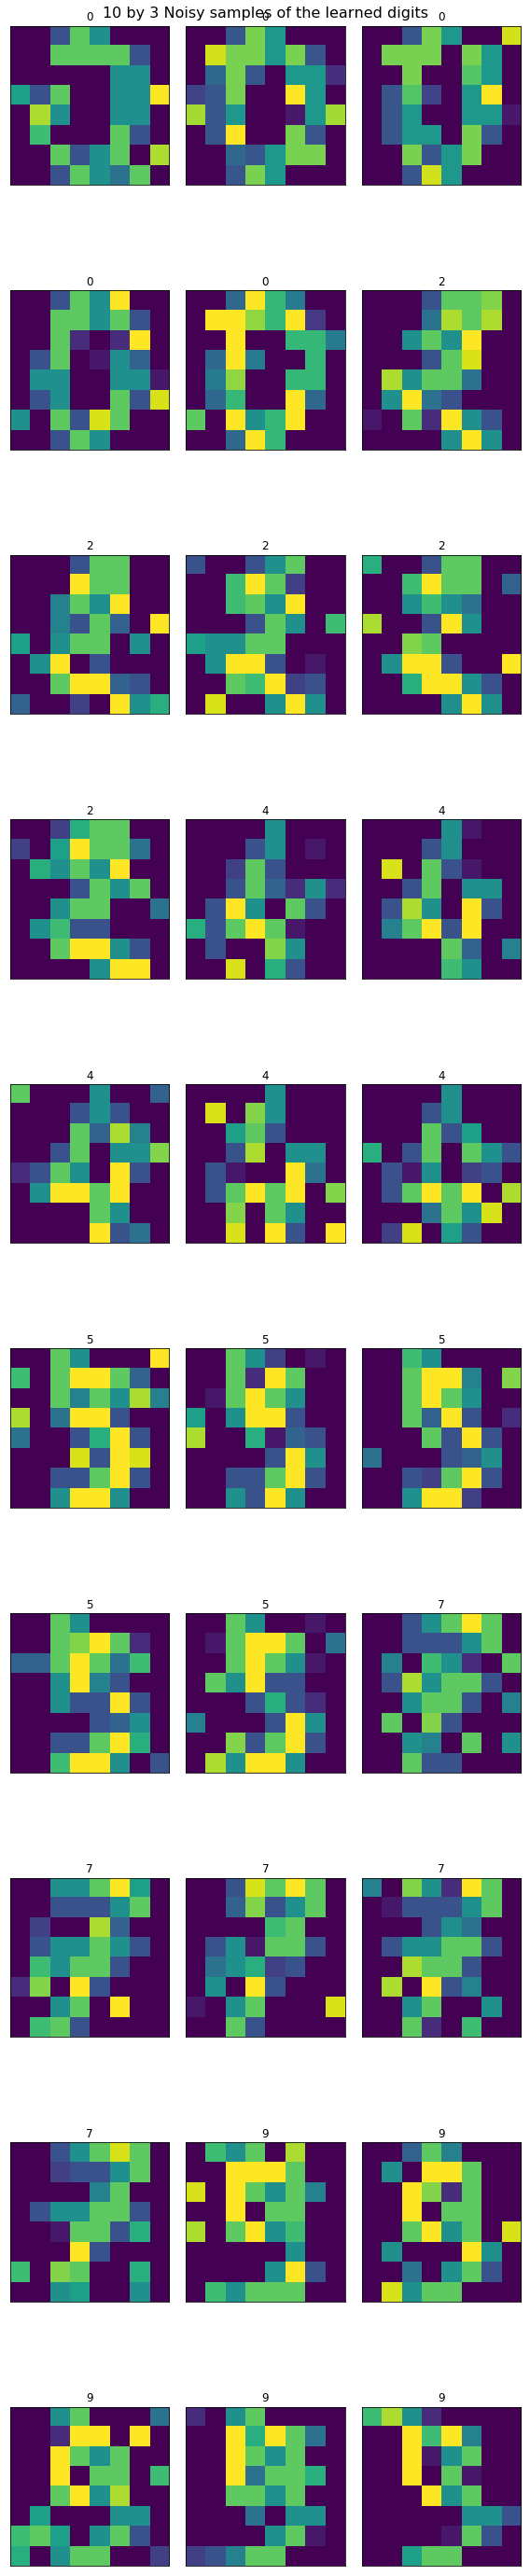

In [8]:
"""
Test Data:

can have 10 rows instead of 2 to show all of test_data
"""
test_digits = repmat(digits, numTestSamples,1).T.flatten()
pre.plot_images(test_digits, test_data, title="10 by 3 Noisy samples of the learned digits",nrows=10, ncols=3)
#pre.plot_images(digits, test_data, title="2 by 3 Noisy samples of the learned digits",nrows=2, ncols=3)

# scaling and defining trainingOdors and testOdors

In [9]:
scale = 15.0

train_data -= train_data.min()
train_data = train_data*(scale/train_data.max())
trainingOdors = train_data.astype(np.int64)

test_data -= test_data.min()
test_data = test_data* scale/test_data.max()
testOdors = test_data.astype(np.int64)

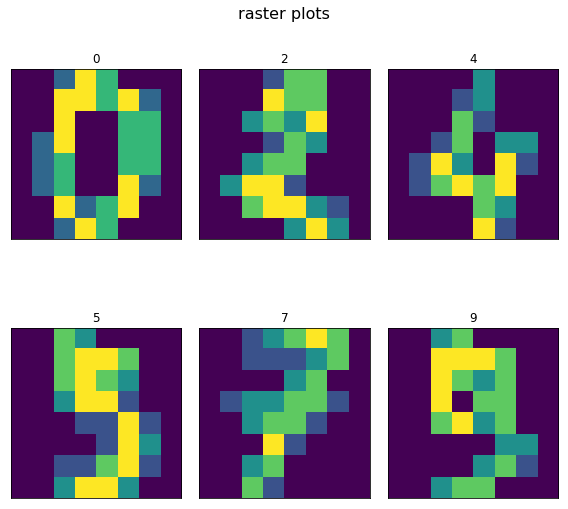

Number of odors to train = 1
Number of odors to test = 30


In [10]:
from lib import epl 
pre.plot_images(digits[:],train_data[:], title="raster plots", nrows=2)


trainingOdors = [testOdors[0]]

nOdors = len(trainingOdors); 
nTestPerOdor = len(testOdors)/nOdors;  
print("Number of odors to train = " + str(len(trainingOdors))); 
print("Number of odors to test = " + str(len(testOdors))); 
#Network initialization
nMCs = len(trainingOdors[0]); 
GCsPerNeurogenesis = 5; 
nGCs = nMCs*GCsPerNeurogenesis*nOdors;     #every MC has 5 GCs per odor  
epl = epl.EPL(nMCs, nGCs, GCsPerNeurogenesis); 

#Sniff
def sniff(odor, learn_flag=0, nGammaPerOdor=5, gPeriod=40):
    sensorInput = OSN.OSN_encoding(odor); 
    for j in range(0, nGammaPerOdor):
        for k in range(0, gPeriod): 
            epl.update(sensorInput, learn_flag=learn_flag);
            pass; 
    epl.reset(); 

#Training
for i in range(0, len(trainingOdors)):
    #print("Training odor " + str(i+1)) 
    sniff(trainingOdors[i], learn_flag=1);
    epl.GClayer.invokeNeurogenesis();
    #sniff(trainingOdors[i], learn_flag=0);

#Testing
for i in range(0, len(testOdors)):
    sniff(testOdors[i], learn_flag=0); 


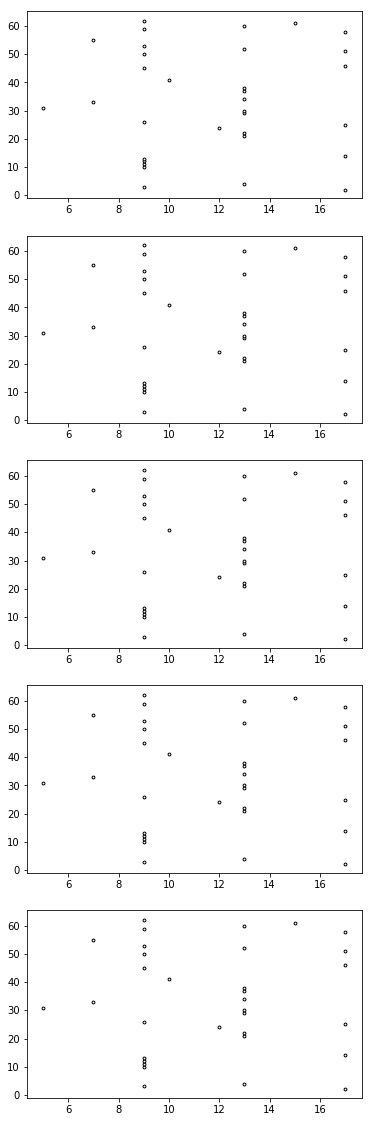

In [11]:
gammaCode = epl.gammaCode
#plotFigure3b(epl.gammaCode, nGamma=5, alignment = '15', figsize = (25,6))
epoch = 1
pre.my_plotFigure3b(epl.gammaCode, epoch, epl.nMCs, nGamma=5)

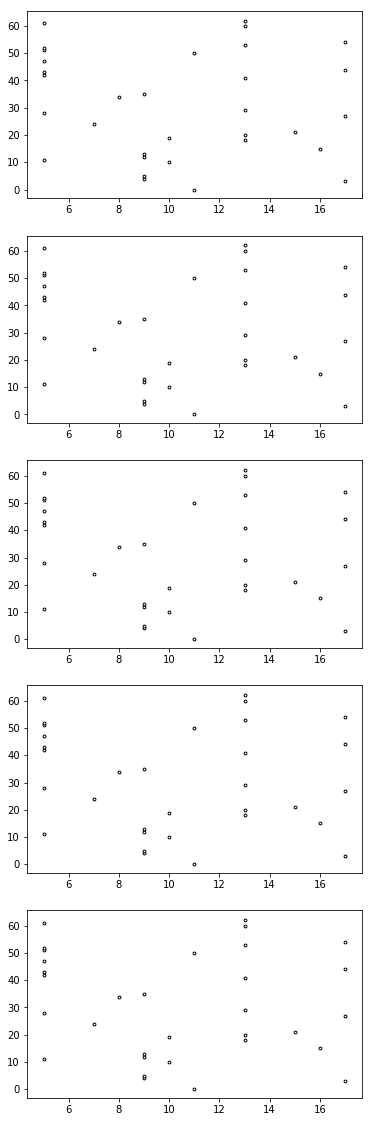

In [12]:
epoch = 9
pre.my_plotFigure3b(epl.gammaCode, epoch, epl.nMCs, nGamma=5)

In [13]:
nOdors = len(trainingOdors)
nTestPerOdor =  len(testOdors)/nOdors -1
sMatrix = readout.readout(epl.gammaCode, nOdors, nTestPerOdor)

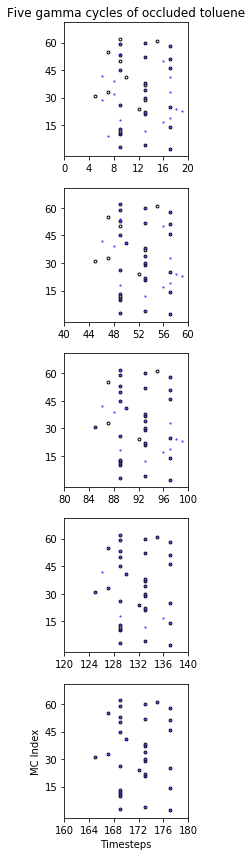

In [14]:
pre.plotFigure3b(epl.gammaCode, epl.nMCs, nGamma=5,figsize = (3,12))

In [15]:
def mymy_plotFigure3b(gammaCode, epoch, nMCs, nGamma = 5, figsize = (6,20)): 
    color = ['k','b', 'g', 'r', 'y', 'm', 'c']
    plt.figure(epoch,figsize)
    alignment = '15' #'15' means 1 row 5 columns and pairs with figsize (20,6)
    #print(str(correlating_digit) + color[epoch-1]) #plt.title(epoch)
    for i in range(0, nGamma):
        s = int(alignment+str(i+1))
        plt.subplot(s);
        if(i==0):
            if epoch == 1:
                plt.title(str(0))
            else:
                plt.title(str(digits[epoch-2]))
        for j in range(0, nMCs):
            #Learned Toluene
            gammaID = epoch*nGamma + i; 
            if gammaCode[gammaID][j] != 0:
                spikeTime = 20 - gammaCode[gammaID][j]; 
                #plt.scatter(spikeTime, j, s= 8, marker = 'o', color = 'w', edgecolor='k')
                plt.scatter(spikeTime, j, s= 8, marker = 'o', color = 'w', edgecolor=color[epoch-1])
    

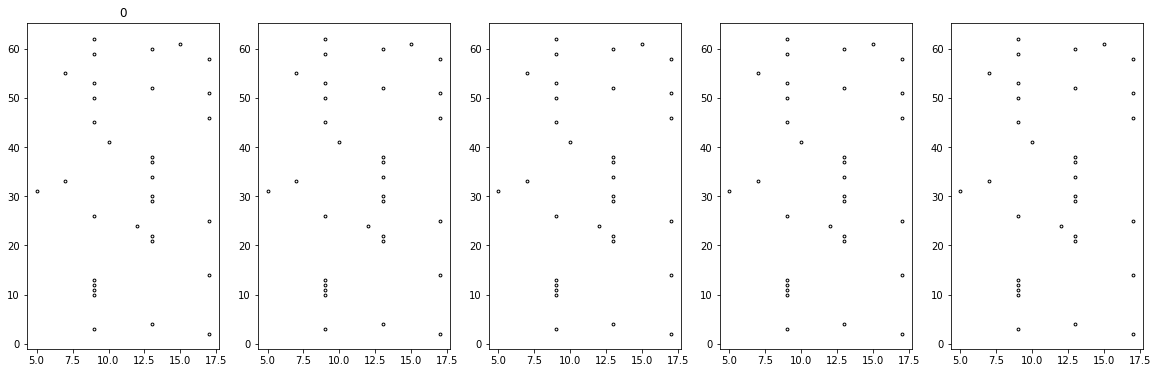

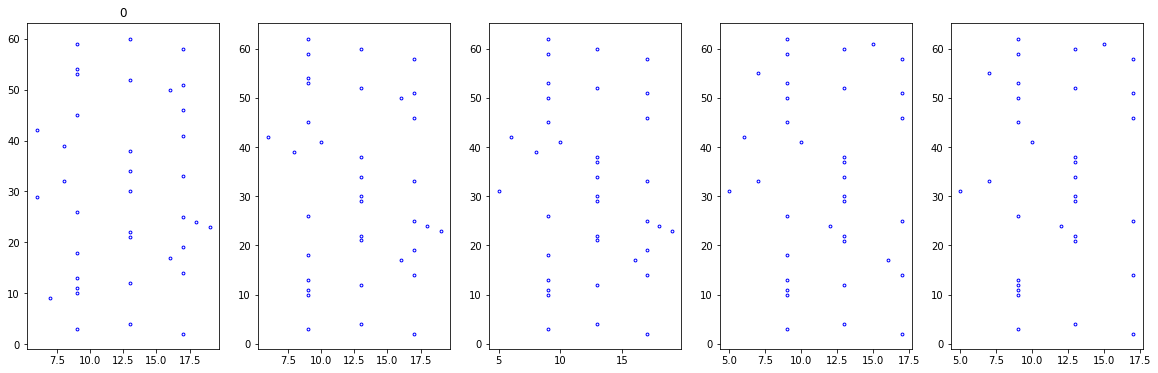

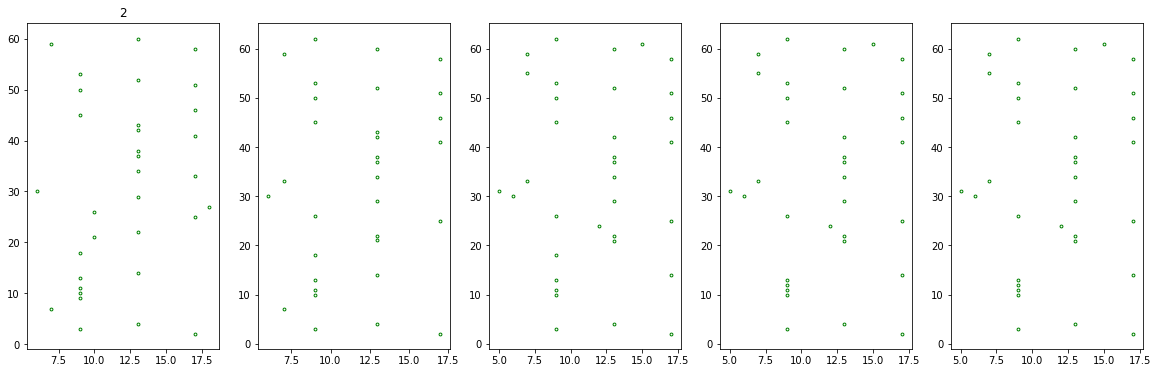

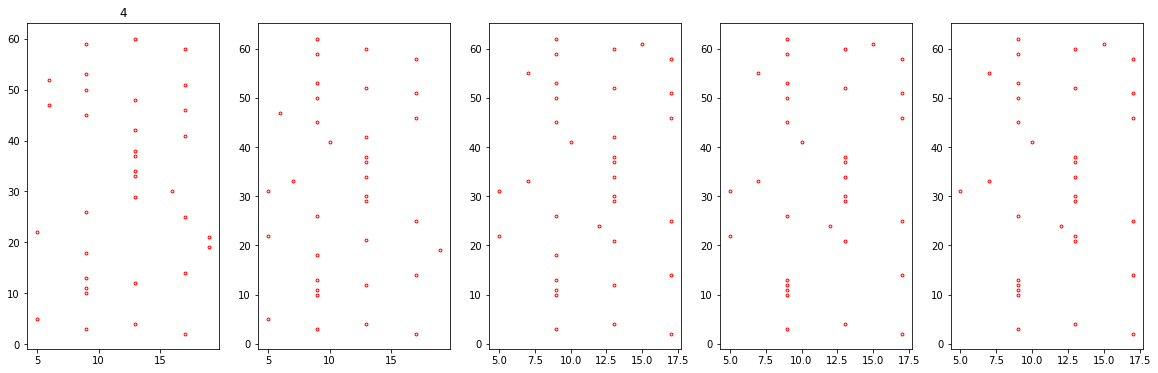

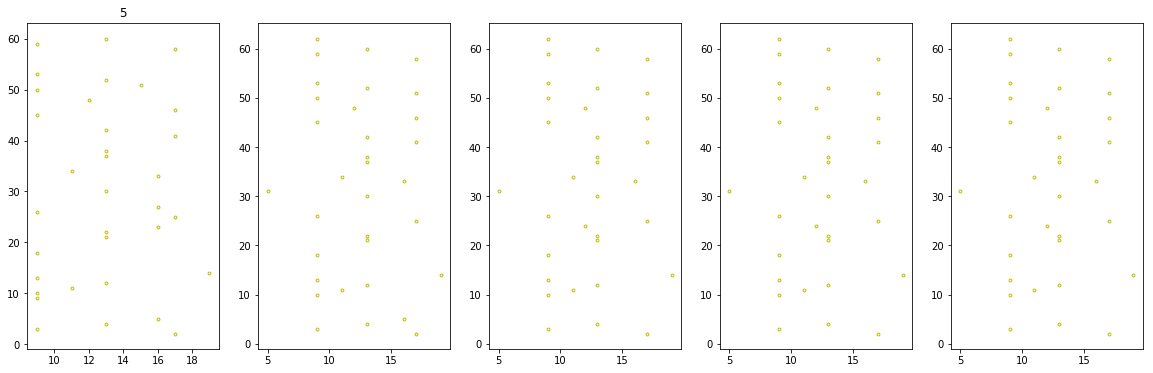

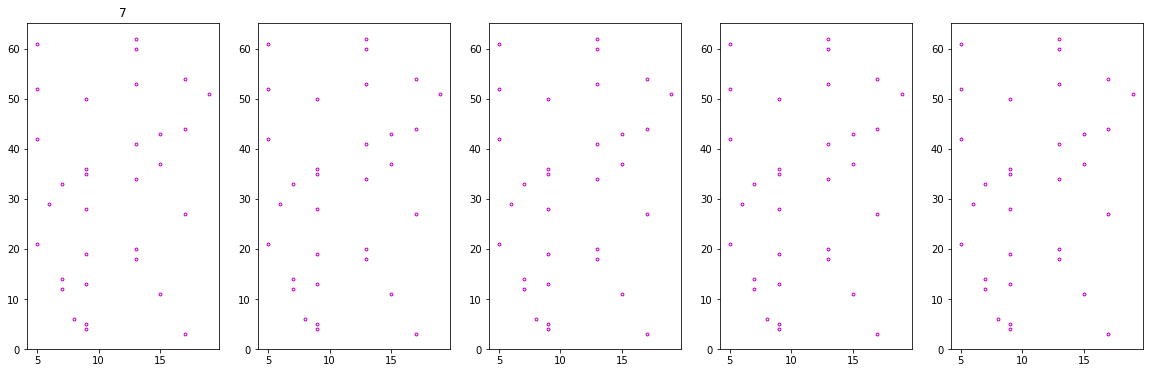

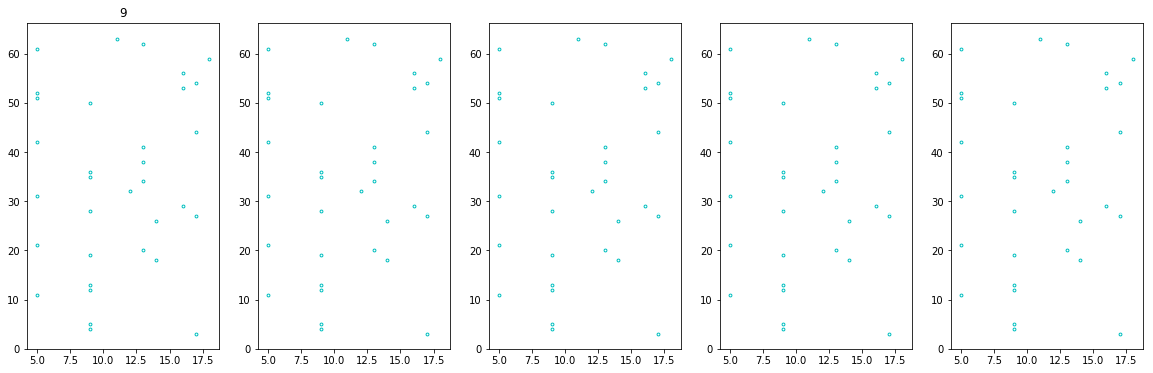

In [16]:
for epoch in range(1,8):
    mymy_plotFigure3b(epl.gammaCode, epoch, epl.nMCs, nGamma=5, figsize = (20,6))


In [17]:
def jaccardSimilarity(l1=[], l2=[]):
    """ computes Jaccard similarity"""
    list1 = []
    list2 = []
    for i in range(0, len(l1)):
        list1.append((i, l1[i]))
        list2.append((i, l2[i]))
    set1 = set(list1)
    set2 = set(list2)
    intersectionSize = len(set.intersection(set1, set2))
    unionSize = len(set.union(set1, set2))
    # print intersectionSize, unionSize;
    return round(intersectionSize/float(unionSize), 4)
def computeSimilarity(l1, l2):
    """ computes similarity index """
    return jaccardSimilarity(l1, l2)

In [18]:
nGamma = 5

In [19]:
computeSimilarity(epl.gammaCode[4],epl.gammaCode[nGamma*4+4])

1.0

In [20]:
true_positive = 0
true_negative = 0
false_positive = 0
false_negative = 0


for i in range(0,1):
    sim = [] #can use np.zeros(len(test_digits))
    for test_digit in range(0,len(test_digits)):
        index = (test_digit+1)* nGamma + nGamma-1 #nGamma-1 to get last of gammaCycle
        sim.append(computeSimilarity(epl.gammaCode[(i+1)* nGamma*nGamma + nGamma-1],epl.gammaCode[index]))

    for sim_index in range(0,len(test_digits)):
        if np.array(sim[sim_index]) > 0.75 and test_digits[sim_index] == test_digits[i*5]: 
            true_positive+=1
        elif np.array(sim[sim_index]) < 0.75 and test_digits[sim_index] == test_digits[i*5]:
            false_negative+=1
        elif np.array(sim[sim_index]) < 0.75 and test_digits[sim_index] != test_digits[i*5]:
            true_negative+=1
        elif np.array(sim[sim_index]) > 0.75 and test_digits[sim_index] != test_digits[i*5]:
            false_positive+=1
        else:
            print("error")

In [21]:
np.array(sim) > 0.75

array([False, False, False, False,  True, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])

In [22]:
test_digits == test_digits[0]

array([ True,  True,  True,  True,  True, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])

In [23]:
true_positive, true_negative, false_positive, false_negative

(1, 25, 0, 4)

In [24]:
len(epl.gammaCode)

155